In [7]:
import os, csv
import matplotlib.pyplot as plt


In [8]:
# global parameters
ref = "outputs/atlas12"
OUT_DIR = "outputs/atlas12+uncond1" 


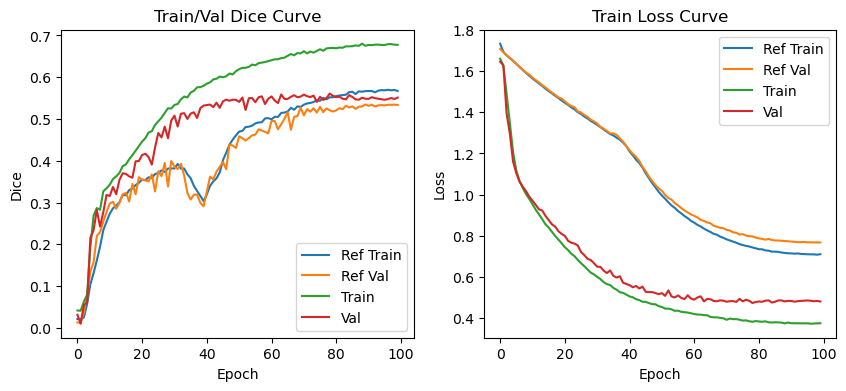

In [9]:
ref_path = os.path.join(ref, "training_log.csv")
log_path = os.path.join(OUT_DIR, "training_log.csv")

def read_log(path):
    with open(path, "r") as f:
        reader = csv.DictReader(f)
        epochs = []
        train_losses = []
        val_losses = []
        train_dices = []
        val_dices = []
        for row in reader:
            epochs.append(int(row["epoch"]))
            train_losses.append(float(row["train_loss"]))
            val_losses.append(float(row["val_loss"]))
            train_dices.append(float(row["train_dice"]))
            val_dices.append(float(row["val_dice"]))

    return epochs, train_losses, val_losses, train_dices, val_dices

ref_epochs, ref_train_losses, ref_val_losses, ref_train_dices, ref_val_dices = read_log(ref_path)
epochs, train_losses, val_losses, train_dices, val_dices = read_log(log_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(ref_train_dices, label="Ref Train")
plt.plot(ref_val_dices, label="Ref Val")
plt.plot(train_dices, label="Train")
plt.plot(val_dices, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.title("Train/Val Dice Curve")
# plt.show()

plt.subplot(1, 2, 2)
plt.plot(ref_train_losses, label="Ref Train")
plt.plot(ref_val_losses, label="Ref Val")
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train Loss Curve")
plt.show()